# Exploratory Data Analysis : Dataset 1
## 140K Real and Fake Faces (Kaggle)

---

## Purpose of this notebook

Before training any model, we must understand our data deeply. This EDA notebook answers:
- What does the dataset look like?
- How are images distributed across splits and classes?
- Are the classes balanced?
- What do real vs fake faces look like visually?
- Are there any quality issues (corrupt files, wrong sizes)?
- What pixel statistics differ between REAL and FAKE?

## Dataset Summary

| Property | Value |
|---|---|
| **Source** | Kaggle : xhlulu/140k-real-and-fake-faces |
| **Total images** | 140,000 |
| **Resolution** | 256×256 px (all identical) |
| **Format** | ImageFolder (subfolders: real / fake) |
| **Real source** | Flickr human face photographs |
| **Fake source** | StyleGAN-generated faces |
| **Balance** | 50% REAL / 50% FAKE (perfectly balanced) |

## Target variable
- `0` = **fake** (AI-generated by StyleGAN)
- `1` = **real** (genuine Flickr photograph)

---

## Step 1 : Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import random
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
# Dataset root
root = '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'
print('Libraries loaded')
print(f'Dataset root: {root}')

Libraries loaded
Dataset root: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake


##  Step 2 : Dataset Structure & Split Counts

The dataset uses PyTorch's `ImageFolder` convention:


In [4]:
splits = ['train', 'valid', 'test']
classes = ['real', 'fake']

records = []
for split in splits:
    for cls in classes:
        path = os.path.join(root, split, cls)
        count = len(os.listdir(path))
        records.append({'Split': split, 'Class': cls.upper(), 'Count': count})

df = pd.DataFrame(records)
print(df.to_string(index=False))
print()
print('Total images:', df['Count'].sum())

# Pivot for display
pivot = df.pivot(index='Split', columns='Class', values='Count')
pivot['Total'] = pivot.sum(axis=1)
pivot.loc['TOTAL'] = pivot.sum()
print()
print(pivot)

Split Class  Count
train  REAL  50000
train  FAKE  50000
valid  REAL  10000
valid  FAKE  10000
 test  REAL  10000
 test  FAKE  10000

Total images: 140000

Class   FAKE   REAL   Total
Split                      
test   10000  10000   20000
train  50000  50000  100000
valid  10000  10000   20000
TOTAL  70000  70000  140000


## Step 3 : Class Balance

Class balance is critical. If one class dominates, the model can cheat by always predicting that class and still appear to have high accuracy. Let's visualize the distribution.

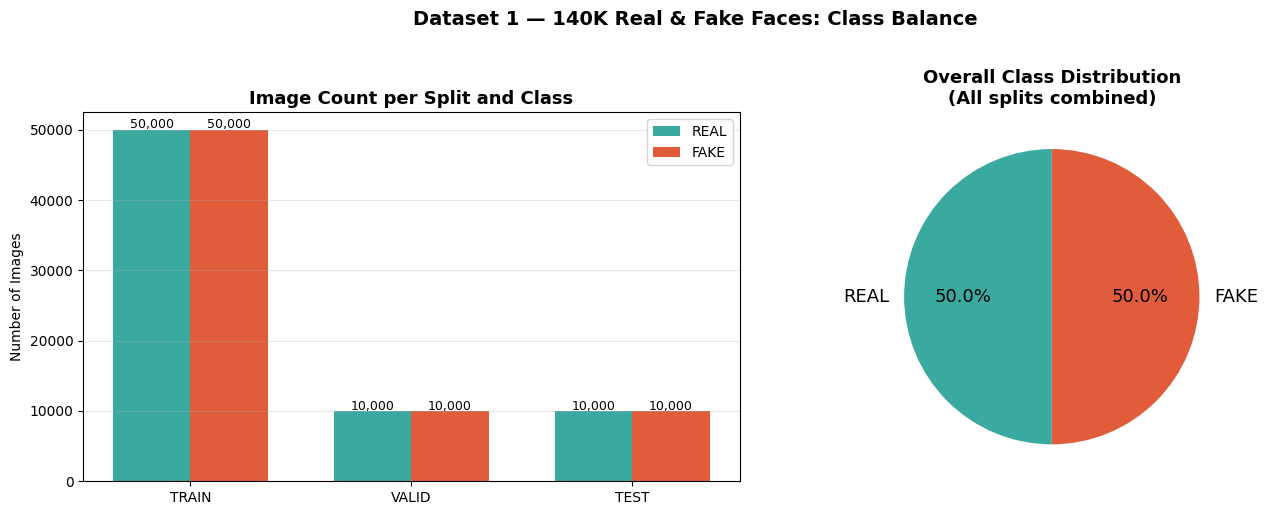

Total REAL: 70,000
Total FAKE: 70,000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


df_plot = df[df['Split'] != 'total']
colors = {'REAL': '#3AA99F', 'FAKE': '#E05C3A'}
x = np.arange(len(splits))
width = 0.35
real_counts = [df[(df['Split']==s) & (df['Class']=='REAL')]['Count'].values[0] for s in splits]
fake_counts = [df[(df['Split']==s) & (df['Class']=='FAKE')]['Count'].values[0] for s in splits]
bars1 = axes[0].bar(x - width/2, real_counts, width, label='REAL', color='#3AA99F')
bars2 = axes[0].bar(x + width/2, fake_counts, width, label='FAKE', color='#E05C3A')
axes[0].set_xticks(x)
axes[0].set_xticklabels([s.upper() for s in splits])
axes[0].set_title('Image Count per Split and Class', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Images')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for bar in bars1: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{int(bar.get_height()):,}', ha='center', fontsize=9)
for bar in bars2: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{int(bar.get_height()):,}', ha='center', fontsize=9)

total_real = sum(real_counts)
total_fake = sum(fake_counts)
axes[1].pie(
    [total_real, total_fake],
    labels=['REAL', 'FAKE'],
    colors=['#3AA99F', '#E05C3A'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 13}
)
axes[1].set_title('Overall Class Distribution\n(All splits combined)', fontweight='bold', fontsize=13)

plt.suptitle('Dataset 1 — 140K Real & Fake Faces: Class Balance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total REAL: {total_real:,}')
print(f'Total FAKE: {total_fake:,}')

## Step 4 : Visual Samples: REAL vs FAKE Faces

Let's look at actual images from both classes. This is the most important EDA step for image datasets , understanding what the model needs to distinguish.

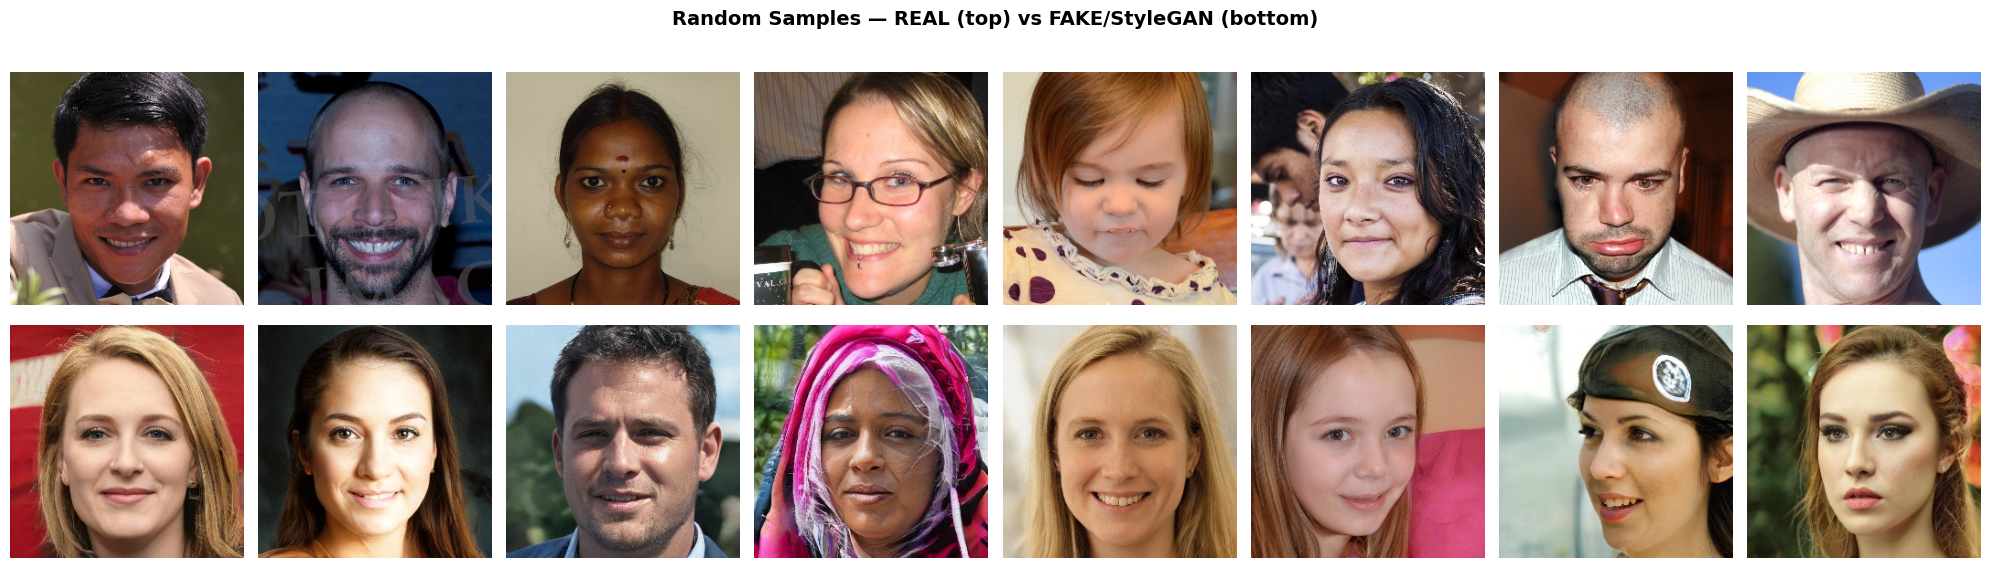

In [ ]:
def load_random_images(split, cls, n=8):
    path   = os.path.join(root, split, cls)
    files  = random.sample(os.listdir(path), n)
    images = [Image.open(os.path.join(path, f)).convert('RGB') for f in files]
    return images

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
real_imgs = load_random_images('train', 'real', 8)
fake_imgs = load_random_images('train', 'fake', 8)
for i, img in enumerate(real_imgs):
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel('REAL', fontsize=13, color='#3AA99F', fontweight='bold')

for i, img in enumerate(fake_imgs):
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel('FAKE', fontsize=13, color='#E05C3A', fontweight='bold')

plt.suptitle('Random Samples : REAL (top) vs FAKE/StyleGAN (bottom)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 : Image Size & Resolution Analysis

All images should be 256×256 px. Let's verify this and check for any corrupt or unexpected files.

In [7]:
sizes  = []
errors = []

for split in splits:
    for cls in classes:
        path = os.path.join(root, split, cls)
        for fname in os.listdir(path)[:500]:  # sample 500 per class per split
            try:
                img = Image.open(os.path.join(path, fname))
                sizes.append({'split': split, 'class': cls, 'width': img.width, 'height': img.height, 'mode': img.mode})
            except Exception as e:
                errors.append({'file': fname, 'error': str(e)})

df_sizes = pd.DataFrame(sizes)
print('=== Image Size Summary ===')
print(df_sizes[['width', 'height']].describe())
print()
print('Unique sizes (W x H):', df_sizes.groupby(['width','height']).size().reset_index(name='count').to_string(index=False))
print()
print('Color modes:', df_sizes['mode'].value_counts().to_dict())
print()
if errors:
    print(f'Corrupt/unreadable files found: {len(errors)}')
else:
    print(' No corrupt files found')

=== Image Size Summary ===
        width  height
count  3000.0  3000.0
mean    256.0   256.0
std       0.0     0.0
min     256.0   256.0
25%     256.0   256.0
50%     256.0   256.0
75%     256.0   256.0
max     256.0   256.0

Unique sizes (W x H):  width  height  count
   256     256   3000

Color modes: {'RGB': 3000}

 No corrupt files found


## Step 6 : Pixel Statistics: REAL vs FAKE
We analyze the **mean brightness** and **color channel distributions** (R, G, B) for real vs fake faces. AI-generated faces (StyleGAN) often have different color statistics than real photographs.

Sampling pixel statistics (this may take a moment)...
Red Channel: REAL mean=0.522 | FAKE mean=0.521
Green Channel: REAL mean=0.424 | FAKE mean=0.426
Blue Channel: REAL mean=0.380 | FAKE mean=0.381
Overall Brightness: REAL mean=0.442 | FAKE mean=0.442


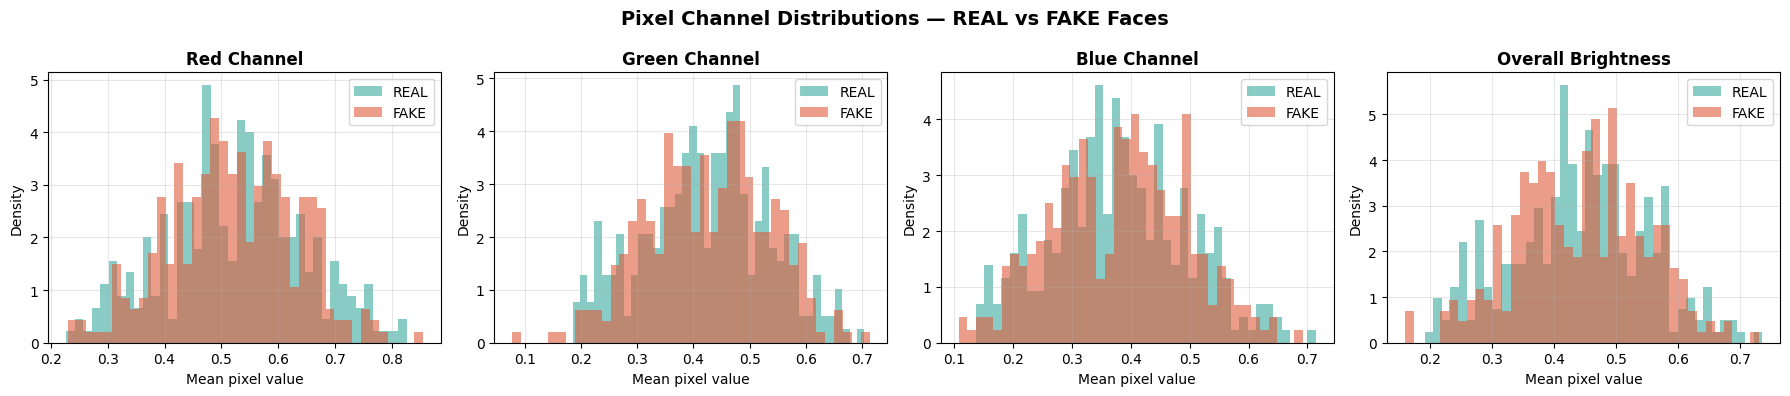

In [8]:
def get_channel_stats(split, cls, n=300):
    path  = os.path.join(root, split, cls)
    files = random.sample(os.listdir(path), min(n, len(os.listdir(path))))
    R, G, B, brightness = [], [], [], []
    for f in files:
        arr = np.array(Image.open(os.path.join(path, f)).convert('RGB')) / 255.0
        R.append(arr[:,:,0].mean())
        G.append(arr[:,:,1].mean())
        B.append(arr[:,:,2].mean())
        brightness.append(arr.mean())
    return np.array(R), np.array(G), np.array(B), np.array(brightness)

print('Sampling pixel statistics (this may take a moment)...')
R_real, G_real, B_real, bright_real = get_channel_stats('train', 'real')
R_fake, G_fake, B_fake, bright_fake = get_channel_stats('train', 'fake')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, real, fake, channel, color in zip(
    axes,
    [R_real, G_real, B_real, bright_real],
    [R_fake, G_fake, B_fake, bright_fake],
    ['Red Channel', 'Green Channel', 'Blue Channel', 'Overall Brightness'],
    ['#E05C5C', '#5CE05C', '#5C8EE0', '#999999']
):
    ax.hist(real, bins=40, alpha=0.6, color='#3AA99F', label='REAL', density=True)
    ax.hist(fake, bins=40, alpha=0.6, color='#E05C3A', label='FAKE', density=True)
    ax.set_title(channel, fontweight='bold')
    ax.set_xlabel('Mean pixel value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    print(f'{channel}: REAL mean={real.mean():.3f} | FAKE mean={fake.mean():.3f}')

plt.suptitle('Pixel Channel Distributions — REAL vs FAKE Faces', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pixel_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 : Average Face: REAL vs FAKE

We compute the **pixel-wise average** of 500 real faces and 500 fake faces. The average face reveals structural differences => AI-generated faces tend to be more symmetric and centered.

Computing average faces...


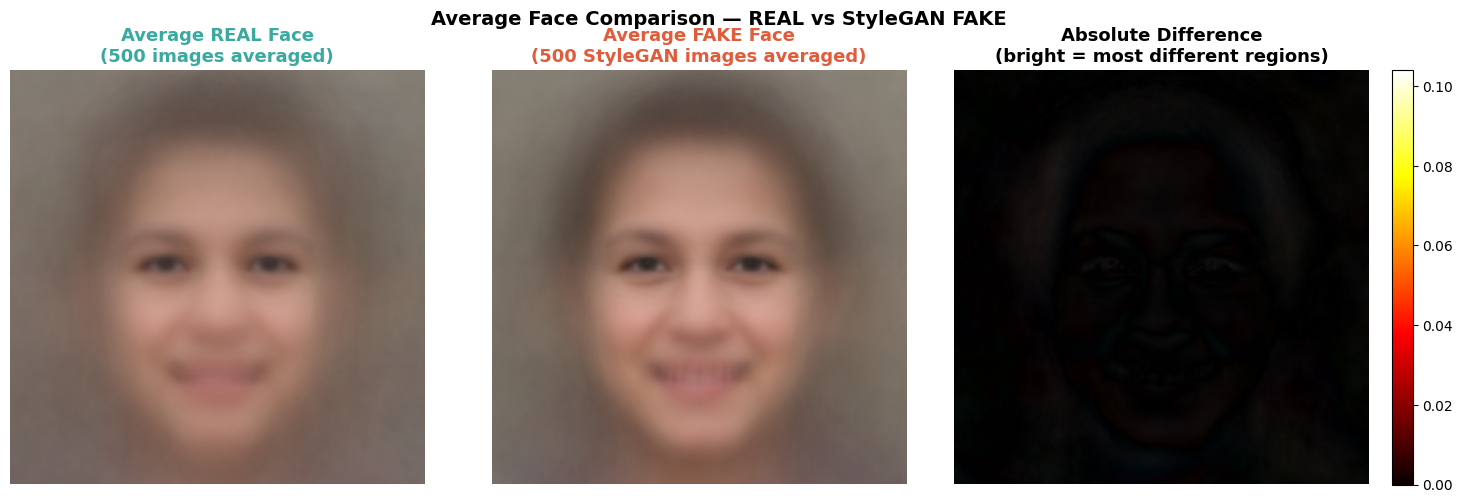

In [9]:
def compute_average_face(split, cls, n=500):
    path  = os.path.join(root, split, cls)
    files = random.sample(os.listdir(path), min(n, len(os.listdir(path))))
    stack = []
    for f in files:
        arr = np.array(Image.open(os.path.join(path, f)).convert('RGB').resize((256,256))) / 255.0
        stack.append(arr)
    return np.mean(stack, axis=0)

print('Computing average faces...')
avg_real = compute_average_face('train', 'real')
avg_fake = compute_average_face('train', 'fake')
diff = np.abs(avg_real - avg_fake)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(avg_real)
axes[0].set_title('Average REAL Face\n(500 images averaged)', fontweight='bold', color='#3AA99F', fontsize=13)
axes[0].axis('off')

axes[1].imshow(avg_fake)
axes[1].set_title('Average FAKE Face\n(500 StyleGAN images averaged)', fontweight='bold', color='#E05C3A', fontsize=13)
axes[1].axis('off')

im = axes[2].imshow(diff, cmap='hot')
axes[2].set_title('Absolute Difference\n(bright = most different regions)', fontweight='bold', fontsize=13)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.suptitle('Average Face Comparison — REAL vs StyleGAN FAKE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('average_faces.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 8 : Sharpness Analysis

AI-generated faces (StyleGAN) are often **unnaturally sharp** : they lack the natural blur and noise found in real photographs. We measure sharpness using the **Laplacian variance** method: higher value = sharper image.

Computing sharpness scores...


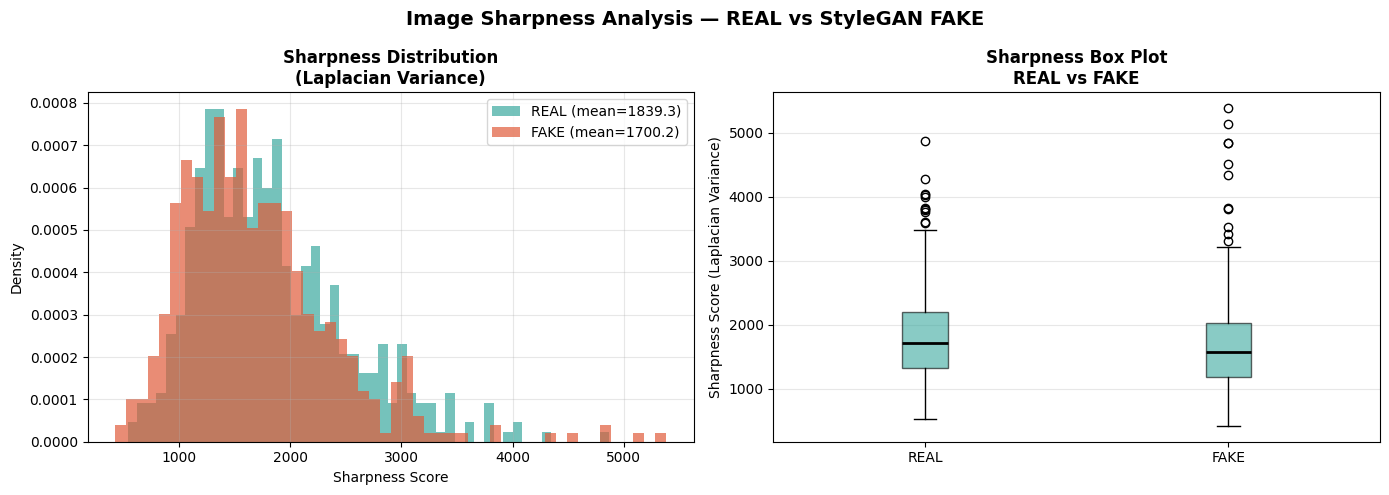

REAL sharpness: mean=1839.27, std=688.53
FAKE sharpness: mean=1700.24, std=697.62


In [10]:
from PIL import ImageFilter

def compute_sharpness(split, cls, n=500):
    path   = os.path.join(root, split, cls)
    files  = random.sample(os.listdir(path), min(n, len(os.listdir(path))))
    scores = []
    for f in files:
        img   = Image.open(os.path.join(path, f)).convert('L')  # grayscale
        arr   = np.array(img, dtype=np.float32)
        # Laplacian variance — measures edge sharpness
        lap   = np.array(img.filter(ImageFilter.FIND_EDGES), dtype=np.float32)
        scores.append(lap.var())
    return np.array(scores)

print('Computing sharpness scores...')
sharp_real = compute_sharpness('train', 'real')
sharp_fake = compute_sharpness('train', 'fake')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(sharp_real, bins=50, alpha=0.7, color='#3AA99F', label=f'REAL (mean={sharp_real.mean():.1f})', density=True)
axes[0].hist(sharp_fake, bins=50, alpha=0.7, color='#E05C3A', label=f'FAKE (mean={sharp_fake.mean():.1f})', density=True)
axes[0].set_title('Sharpness Distribution\n(Laplacian Variance)', fontweight='bold')
axes[0].set_xlabel('Sharpness Score')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot([sharp_real, sharp_fake], labels=['REAL', 'FAKE'],
                patch_artist=True,
                boxprops=dict(facecolor='#3AA99F', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Sharpness Box Plot\nREAL vs FAKE', fontweight='bold')
axes[1].set_ylabel('Sharpness Score (Laplacian Variance)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Image Sharpness Analysis — REAL vs StyleGAN FAKE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sharpness.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'REAL sharpness: mean={sharp_real.mean():.2f}, std={sharp_real.std():.2f}')
print(f'FAKE sharpness: mean={sharp_fake.mean():.2f}, std={sharp_fake.std():.2f}')